In [ ]:
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np

import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


import pickle

In [ ]:
housing = pd.read_csv('/content/sample_data/housing.csv')

In [ ]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


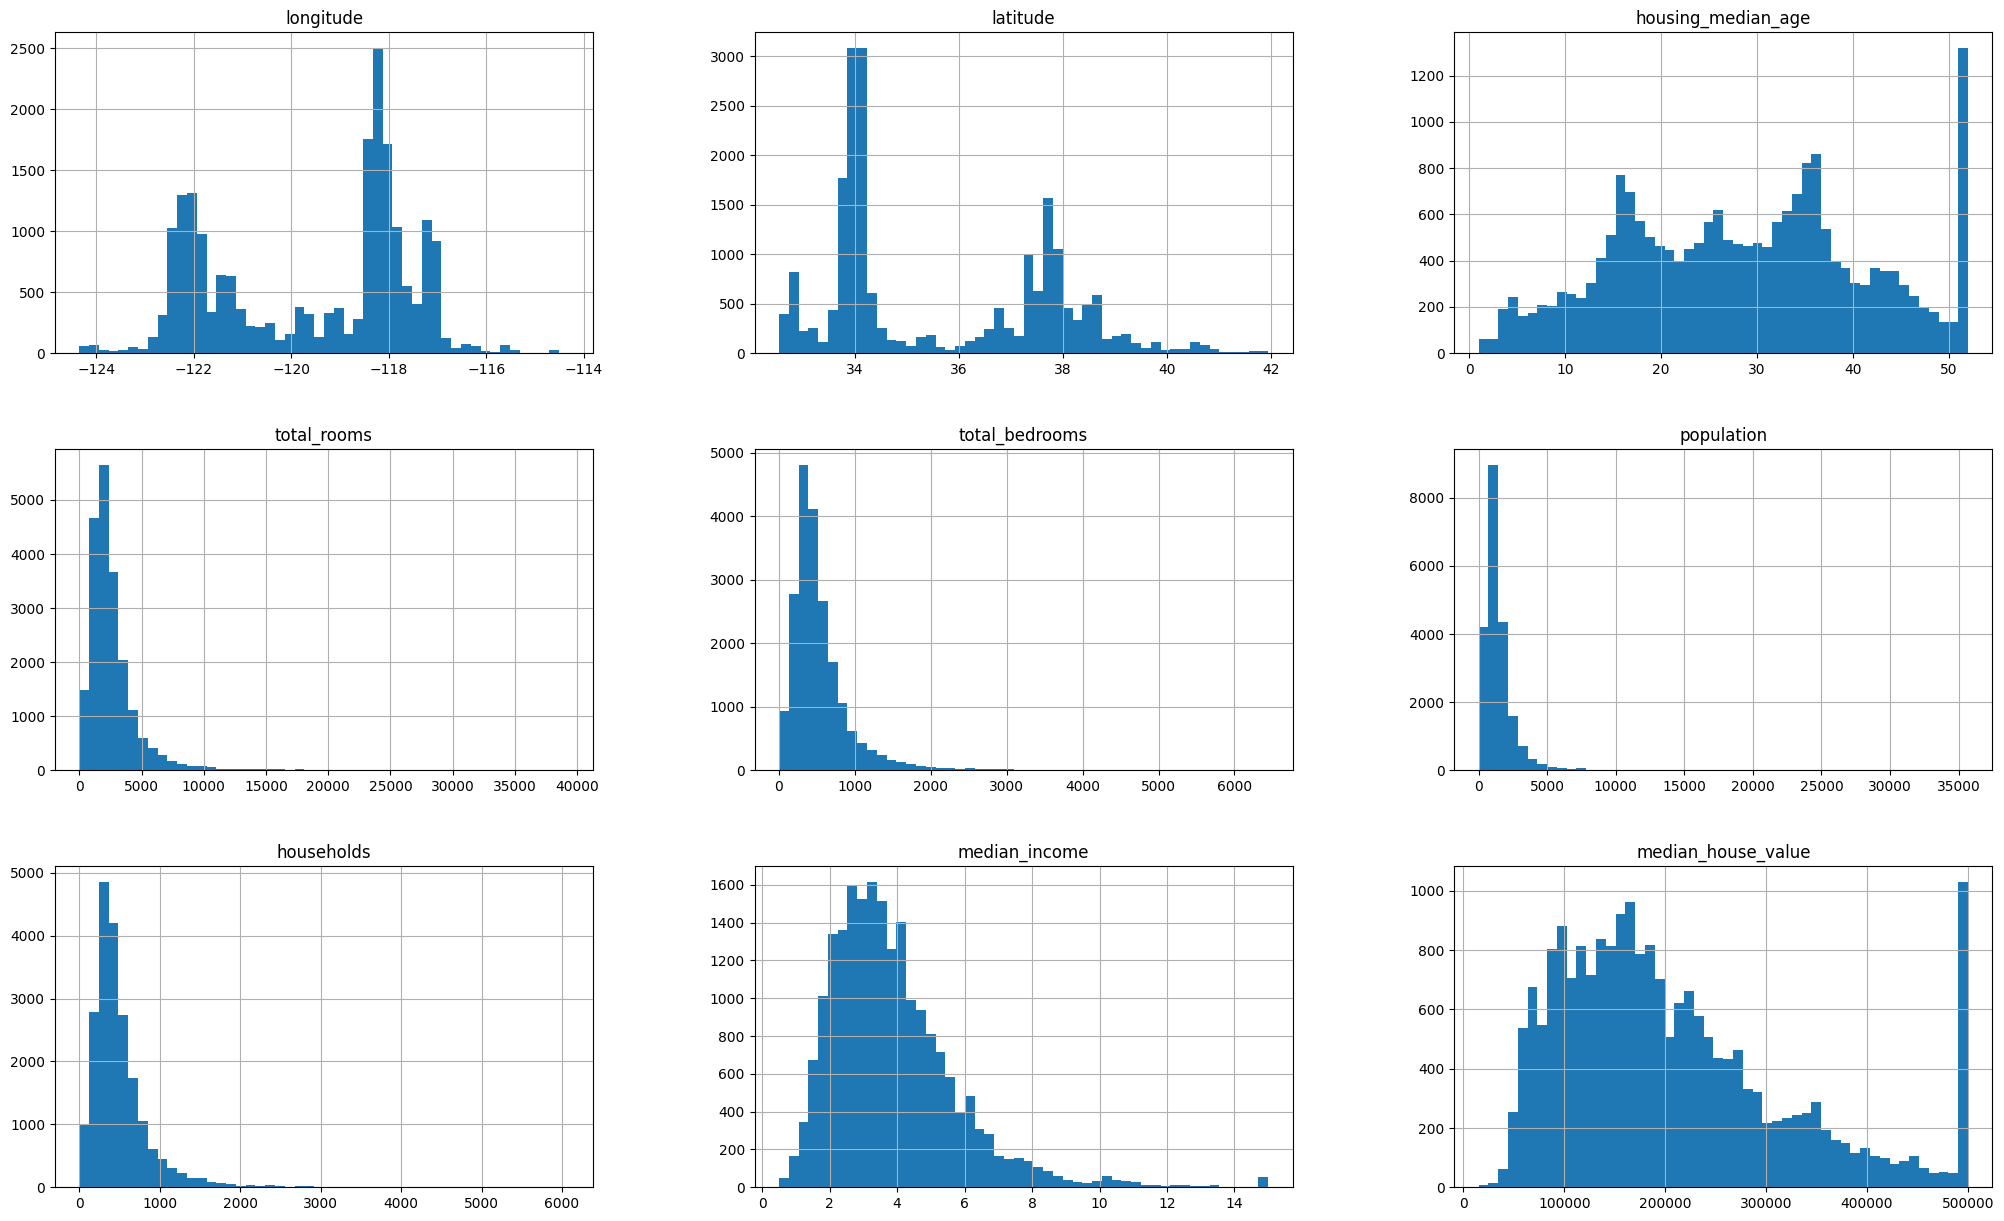

In [ ]:
housing.hist(bins=50, figsize=(25,15))
plt.show()

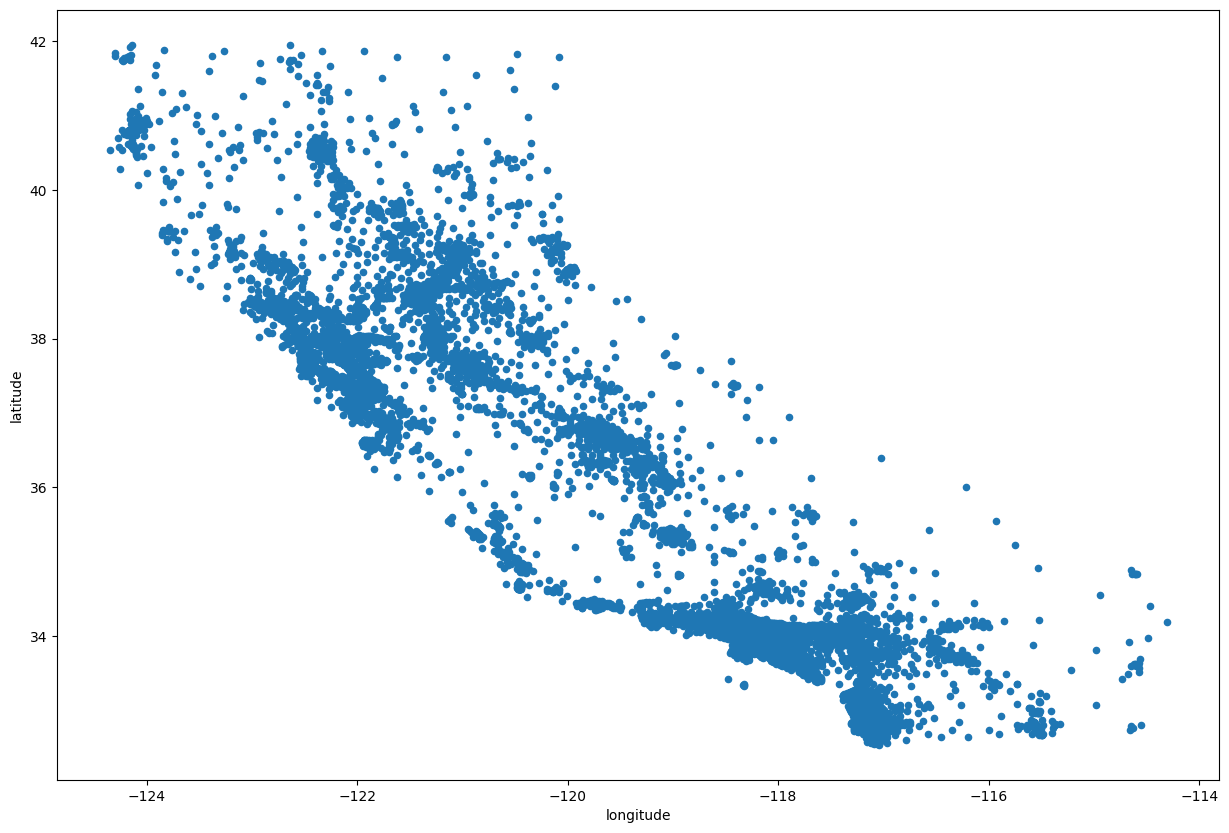

In [ ]:
housing.plot(kind='scatter',x='longitude', y='latitude', figsize=(15,10))
plt.show()

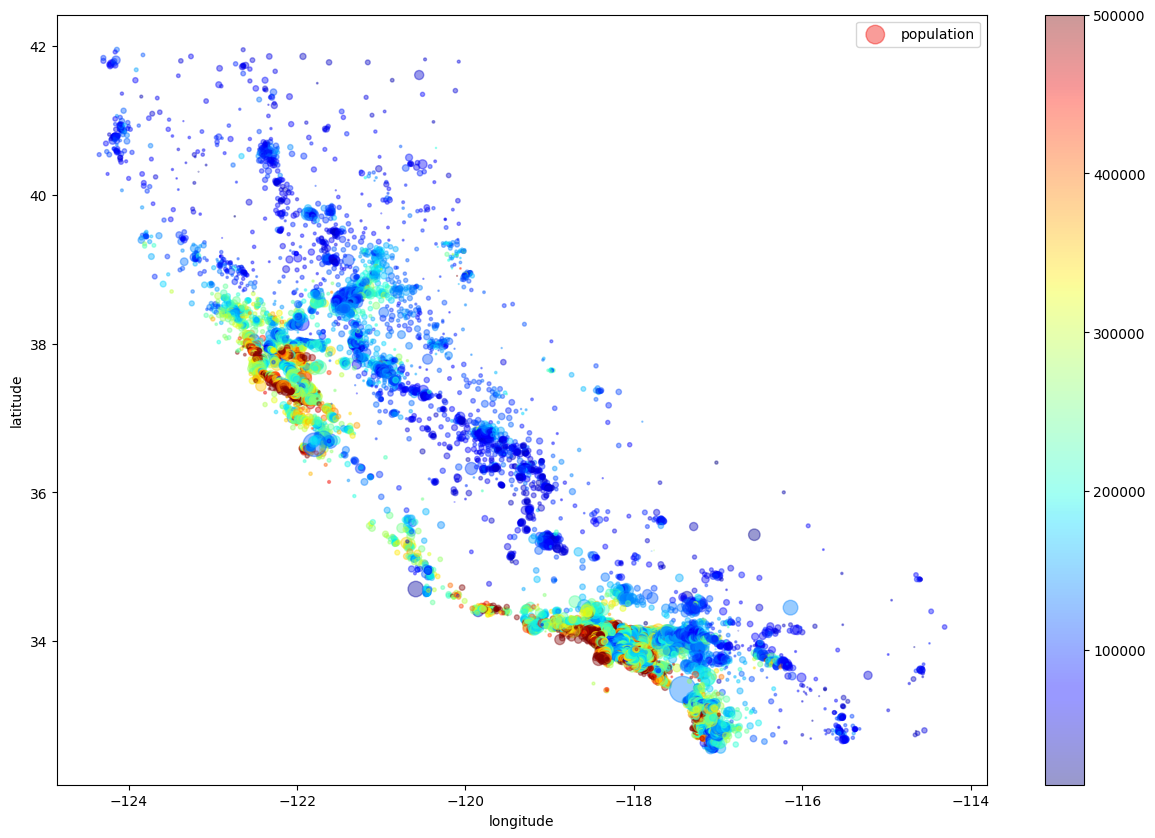

In [ ]:
housing.plot(kind='scatter',x='longitude', y='latitude', alpha=0.4, s=housing['population']/100, label='population',
             figsize=(15,10), c=housing['median_house_value'], cmap=plt.get_cmap('jet'), colorbar=True )
plt.legend()
plt.show()

In [ ]:
corr_matrix = housing.drop('ocean_proximity', axis=1).corr()

corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


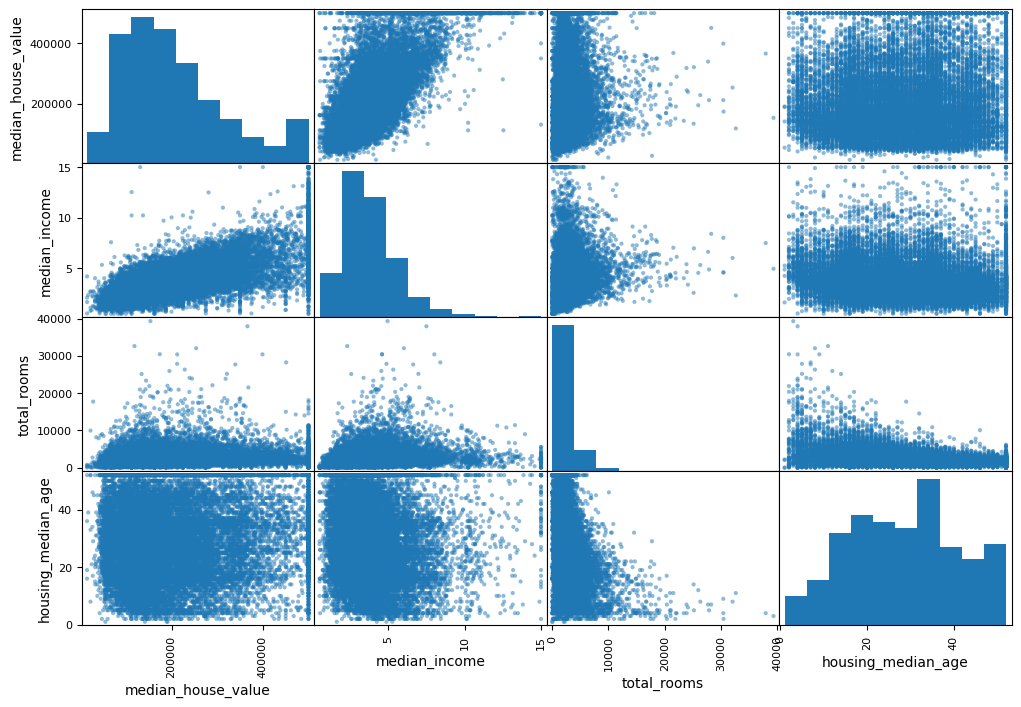

In [ ]:
attributes = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']
scatter_matrix(housing[attributes], figsize=(12,8))
plt.show()

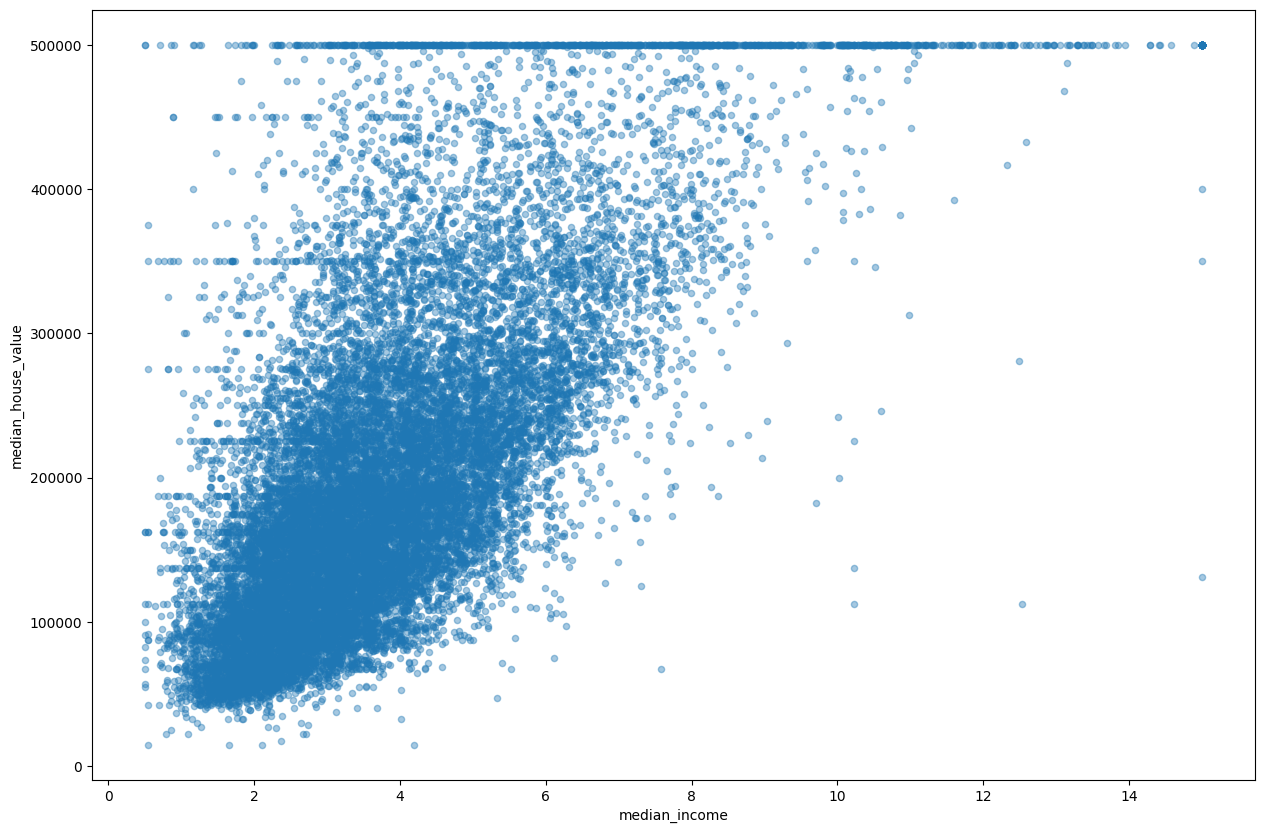

In [ ]:
housing.plot(kind='scatter', x='median_income', y='median_house_value', alpha=0.4, figsize=(15,10) )
plt.show()

In [ ]:
train, test = train_test_split(housing, test_size = 0.2, random_state = 42)

In [ ]:
train.shape, test.shape

((16512, 10), (4128, 10))

In [ ]:
housing.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
imputer = SimpleImputer(strategy="median")


test_num = test.drop("ocean_proximity", axis=1)
test_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4128 entries, 20046 to 3665
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           4128 non-null   float64
 1   latitude            4128 non-null   float64
 2   housing_median_age  4128 non-null   float64
 3   total_rooms         4128 non-null   float64
 4   total_bedrooms      3921 non-null   float64
 5   population          4128 non-null   float64
 6   households          4128 non-null   float64
 7   median_income       4128 non-null   float64
 8   median_house_value  4128 non-null   float64
dtypes: float64(9)
memory usage: 322.5 KB


In [ ]:
imputer.fit(test_num)

SimpleImputer(strategy='median')

In [ ]:
imputer.statistics_

array([-1.1847e+02,  3.4230e+01,  2.9000e+01,  2.1100e+03,  4.2800e+02,
        1.1600e+03,  4.0600e+02,  3.5000e+00,  1.7865e+05])

In [ ]:
test_num.median().values

array([-1.1847e+02,  3.4230e+01,  2.9000e+01,  2.1100e+03,  4.2800e+02,
        1.1600e+03,  4.0600e+02,  3.5000e+00,  1.7865e+05])

In [ ]:
X = imputer.transform(test_num)

In [ ]:
test_tr = pd.DataFrame(X, columns = test_num.columns)
test_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-119.01,36.06,25.0,1505.0,428.0,1392.0,359.0,1.6812,47700.0
1,-119.46,35.14,30.0,2943.0,428.0,1565.0,584.0,2.5313,45800.0
2,-122.44,37.80,52.0,3830.0,428.0,1310.0,963.0,3.4801,500001.0
3,-118.72,34.28,17.0,3051.0,428.0,1705.0,495.0,5.7376,218600.0
4,-121.93,36.62,34.0,2351.0,428.0,1063.0,428.0,3.7250,278000.0
...,...,...,...,...,...,...,...,...,...
4123,-117.22,33.36,16.0,3165.0,482.0,1351.0,452.0,4.6050,263300.0
4124,-120.83,35.36,28.0,4323.0,886.0,1650.0,705.0,2.7266,266800.0
4125,-122.05,37.31,25.0,4111.0,538.0,1585.0,568.0,9.2298,500001.0
4126,-119.76,36.77,36.0,2507.0,466.0,1227.0,474.0,2.7850,72300.0


In [ ]:
test["rooms_per_household"]=test["total_rooms"]/test["households"]
test["bedrooms_per_room"]=test["total_bedrooms"]/test["total_rooms"]
test["population_per_household"]=test["population"]/test["households"]
test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND,4.192201,NaN,3.877437
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND,5.039384,NaN,2.679795
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY,3.977155,NaN,1.360332
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN,6.163636,NaN,3.444444
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN,5.492991,NaN,2.483645
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15362,-117.22,33.36,16.0,3165.0,482.0,1351.0,452.0,4.6050,263300.0,<1H OCEAN,7.002212,0.152291,2.988938
16623,-120.83,35.36,28.0,4323.0,886.0,1650.0,705.0,2.7266,266800.0,NEAR OCEAN,6.131915,0.204950,2.340426
18086,-122.05,37.31,25.0,4111.0,538.0,1585.0,568.0,9.2298,500001.0,<1H OCEAN,7.237676,0.130868,2.790493
2144,-119.76,36.77,36.0,2507.0,466.0,1227.0,474.0,2.7850,72300.0,INLAND,5.289030,0.185880,2.588608


In [ ]:
test_labels=test['median_house_value'].copy()

test=test.drop('median_house_value', axis=1)

test_num=test.drop("ocean_proximity", axis=1)

test_labels.head()

,median_house_value
20046,47700.0
3024,45800.0
15663,500001.0
20484,218600.0
9814,278000.0


In [ ]:
num_pipeline = Pipeline([('imputer',SimpleImputer(strategy="median")),('std_scaler', StandardScaler())])

test_tr = num_pipeline.fit_transform(test_num)

num_attribs = list(test_num)
cat_attribs = ["ocean_proximity"]
full_pipeline = ColumnTransformer([("num", num_pipeline, num_attribs), ("cat",OneHotEncoder(), cat_attribs) ])
test_prepared = full_pipeline.fit_transform(test)

In [ ]:
test_prepared.shape

(4128, 16)

In [ ]:
from sklearn.datasets import make_regression

forest_reg = RandomForestRegressor()
X, Y = make_regression(n_features=16, n_informative=2,random_state=0, shuffle=False)
forest_reg.fit(X,Y)
test_prediction = forest_reg.predict(test_prepared)
test_prediction

array([ 22.01771037,  -9.0733391 , 125.94933673, ...,  24.95165813,
        36.53127872, -34.63899724])

In [ ]:
lin_reg = LinearRegression()


test_forest_mse = mean_squared_error(test_labels, test_prediction)
test_forest_rmse = np.sqrt(test_forest_mse)


test_forest_rmse_scores = cross_val_score(forest_reg, test_prepared, test_labels, scoring='neg_mean_squared_error', cv=10)
forest_tree_rmse_scores = np.sqrt(-test_forest_rmse_scores)


def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())


display_scores(forest_tree_rmse_scores)

Scores: [53690.01368687 52148.47006155 57178.66118292 61931.83598877
 54437.35213669 51484.14515355 52420.5981419  58545.18196853
 57952.26950837 54142.81629253]
Mean: 55393.1344121685
Standard deviation: 3200.7616501189345


In [ ]:
lin_scores = cross_val_score(lin_reg, test_prepared, test_labels, scoring='neg_mean_squared_error', cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)


display_scores(lin_rmse_scores)

Scores: [67404.97038787 69127.6550799  75864.82154489 72152.56108756
 72250.30236857 64321.316356   67504.69067265 74197.44724277
 68214.96737372 71915.32682217]
Mean: 70295.40589361062
Standard deviation: 3371.400716362218


In [ ]:
param_grid=[{'n_estimators': [3,10,30],'max_features': [2,4,6,8]},
            {'bootstrap': [False],'n_estimators': [3,10],'max_features': [2,3,4] } ]


grid_search = GridSearchCV(forest_reg, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(test_prepared, test_labels)


cvres=grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

71950.16563136484 {'max_features': 2, 'n_estimators': 3}
61502.287179016574 {'max_features': 2, 'n_estimators': 10}
58920.79247098949 {'max_features': 2, 'n_estimators': 30}
66873.14273117218 {'max_features': 4, 'n_estimators': 3}
58704.01356908538 {'max_features': 4, 'n_estimators': 10}
56071.38225916671 {'max_features': 4, 'n_estimators': 30}
65774.55028713742 {'max_features': 6, 'n_estimators': 3}
58159.41404766482 {'max_features': 6, 'n_estimators': 10}
55631.89558138471 {'max_features': 6, 'n_estimators': 30}
63524.00972828253 {'max_features': 8, 'n_estimators': 3}
57199.83758079582 {'max_features': 8, 'n_estimators': 10}
55358.23037462111 {'max_features': 8, 'n_estimators': 30}
69051.98444186125 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
59776.104203349656 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
66740.33080802065 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
59597.79890138609 {'bootstrap': False, 'max_features': 3, 'n_estimators': 

In [ ]:
import pickle

filename = 'final_rf_model.sav'
pickle.dump(grid_search.best_estimator_, open(filename, 'wb'))